# Task 4: Prediction: Training & Testing
**Student Dropout and Academic Success Dataset**
This notebook covers:
1. Load preprocessed data
2. Train three classification models (Decision Tree, Logistic Regression, SVM)
3. Evaluate on train, test, and entire set
4. Confusion matrix visualization
5. Decision boundary visualization
6. Model performance comparison

In [1]:
import sys
import os
#  Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from src.prediction import train_model, predict_and_evaluate, plot_confusion_matrix, plot_decision_boundary
#  / Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
#  / Plot save directory
PLOT_DIR = os.path.join(project_root, "data", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

## 1. Load Data
Using engineered feature dataset from NB01 (OOF target encoded + feature selected).

In [2]:
# // / Load engineered train/val/test sets
data_dir = os.path.join(project_root, "data")
X_train = pd.read_csv(os.path.join(data_dir, "features_engineered_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "targets_engineered_train.csv")).iloc[:, 0]
X_val = pd.read_csv(os.path.join(data_dir, "features_engineered_val.csv"))
y_val = pd.read_csv(os.path.join(data_dir, "targets_engineered_val.csv")).iloc[:, 0]
X_test = pd.read_csv(os.path.join(data_dir, "features_engineered_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "targets_engineered_test.csv")).iloc[:, 0]

print(X_train.shape, y_train.shape)
#  engineered top-40  / Verify engineered top-40 feature space
assert X_train.shape[1] == 40, f"Expected 40 engineered features, got {X_train.shape[1]}"
assert X_val.shape[1] == 40, f"Expected 40 engineered features, got {X_val.shape[1]}"
assert X_test.shape[1] == 40, f"Expected 40 engineered features, got {X_test.shape[1]}"
#  "entire set"  / Combine for entire-set evaluation
X_all = pd.concat([X_train, X_val, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_val, y_test], ignore_index=True)
print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"All:   {X_all.shape}")
print("\nClass distribution (train):")
print(y_train.value_counts().sort_index())

(3096, 40) (3096,)
Train: (3096, 40)
Val:   (664, 40)
Test:  (664, 40)
All:   (4424, 40)

Class distribution (train):
Target
0     995
1     556
2    1545
Name: count, dtype: int64


## 2. Model Training
Training three classifiers:
- **Decision Tree**: tree model based on information gain, highly interpretable
- **Logistic Regression**: linear classifier, serves as a strong baseline
- **SVM (RBF kernel)**: kernel method, effective for non-linear decision boundaries

In [3]:
#  src.prediction  baseline  / Define baseline models aligned with src.prediction defaults
baseline_models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        class_weight="balanced",
    ),
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=50000,
        solver="saga",
        class_weight="balanced",
    ),
    "SVM (RBF)": SVC(
        random_state=42,
        kernel="rbf",
        probability=True,
        class_weight="balanced",
    ),
}
#  baseline  / Train all baseline models
trained_models = {}
for name, model in baseline_models.items():
    print()
    model.fit(X_train.values, y_train.values)
    trained_models[name] = model
    print(f'Training complete: {name}')


Training complete: Decision Tree

Training complete: Logistic Regression

Training complete: SVM (RBF)


## 3. Model Evaluation

In [4]:
#  / Evaluate all models on four sets
all_results = {}
eval_sets = [
    ("Train", X_train.values, y_train.values),
    ("Val", X_val.values, y_val.values),
    ("Test", X_test.values, y_test.values),
    ("Entire", X_all.values, y_all.values),
]
for model_name, model in trained_models.items():
    print()
    print(f"Model: {model_name}")
    for set_name, X_set, y_set in eval_sets:
        key = f"{model_name}_{set_name}"
        all_results[key] = predict_and_evaluate(model, X_set, y_set, set_name=f"{model_name} - {set_name}")


Model: Decision Tree
[Decision Tree - Train] Accuracy: 0.9047
[Decision Tree - Val] Accuracy: 0.7108
[Decision Tree - Test] Accuracy: 0.7123
[Decision Tree - Entire] Accuracy: 0.8467

Model: Logistic Regression
[Logistic Regression - Train] Accuracy: 0.7545
[Logistic Regression - Val] Accuracy: 0.7440
[Logistic Regression - Test] Accuracy: 0.7410
[Logistic Regression - Entire] Accuracy: 0.7509

Model: SVM (RBF)
[SVM (RBF) - Train] Accuracy: 0.8026
[SVM (RBF) - Val] Accuracy: 0.7289
[SVM (RBF) - Test] Accuracy: 0.7319
[SVM (RBF) - Entire] Accuracy: 0.7810


## 4. Confusion Matrix Visualization
Plot confusion matrix heatmaps for each model on the test set.

Plot saved to: data/plots/04_confusion_matrix_lr_only.png


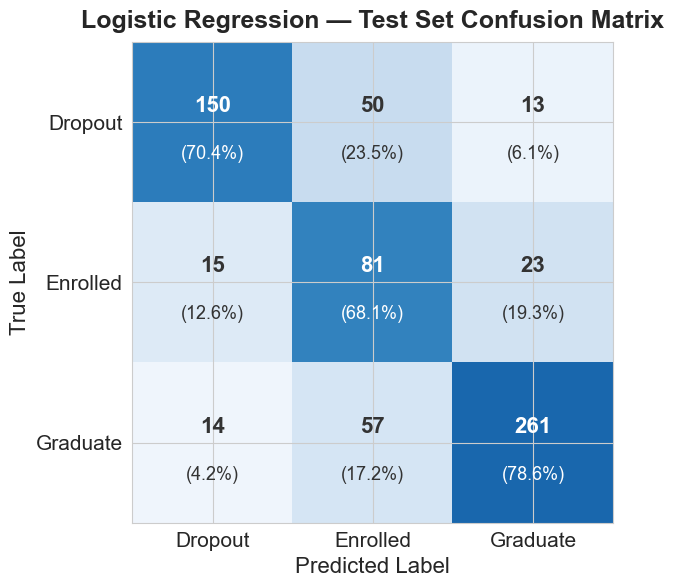

In [12]:
#  LR  () —  / Plot LR confusion matrix (test set) — single large figure
from sklearn.metrics import confusion_matrix
lr_model = trained_models["Logistic Regression"]
y_pred_lr = lr_model.predict(X_test.values)
cm = confusion_matrix(y_test.values, y_pred_lr)
class_labels = ["Dropout", "Enrolled", "Graduate"]
fig, ax = plt.subplots(figsize=(7, 6))
#  / Row-normalize for coloring
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
#  / Show count and percentage per cell
for i in range(3):
    for j in range(3):
        pct = cm[i, j] / cm[i].sum() * 100
        color = "white" if cm_norm[i, j] > 0.5 else "#333333"
        ax.text(j, i - 0.1, f"{cm[i, j]}", ha="center", va="center",
                fontsize=16, fontweight="bold", color=color)
        ax.text(j, i + 0.2, f"({pct:.1f}%)", ha="center", va="center",
                fontsize=13, color=color)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_labels, fontsize=15)
ax.set_yticklabels(class_labels, fontsize=15)
ax.set_xlabel("Predicted Label", fontsize=16)
ax.set_ylabel("True Label", fontsize=16)
ax.set_title("Logistic Regression — Test Set Confusion Matrix", fontsize=18, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_confusion_matrix_lr_only.png"), dpi=200, bbox_inches="tight",
            facecolor="white")
print("Plot saved to: data/plots/04_confusion_matrix_lr_only.png")
plt.show()

Plot saved to data/plots/04_confusion_matrices_train.png


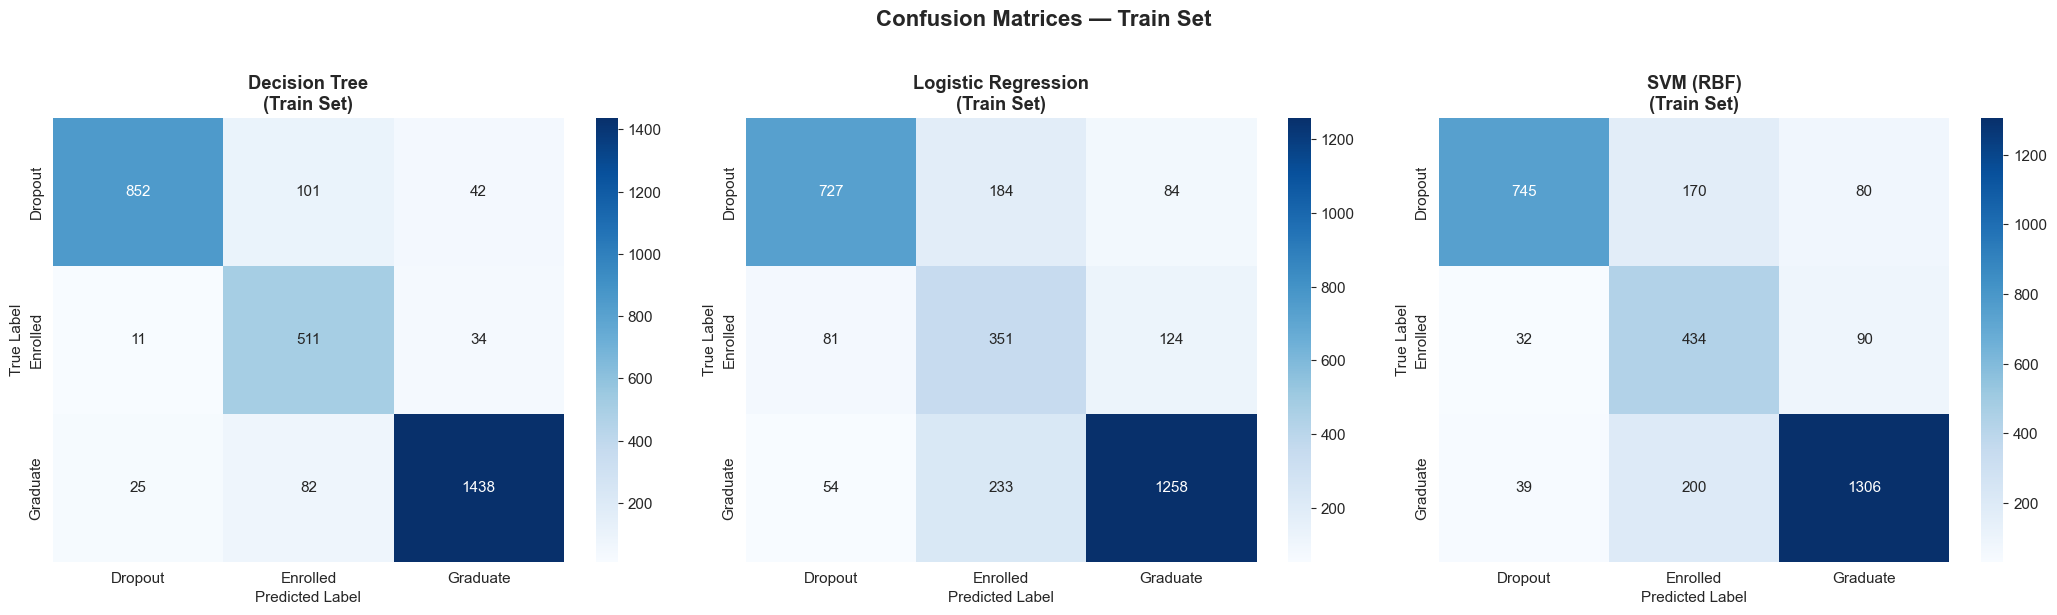

In [6]:
#  () / Plot confusion matrices (train set)
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (model_name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_train.values)
    plot_confusion_matrix(
        y_train.values, y_pred,
        title=f"{model_name}\n(Train Set)",
        ax=ax,
    )
plt.suptitle("Confusion Matrices — Train Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_confusion_matrices_train.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to data/plots/04_confusion_matrices_train.png")
plt.show()

Plot saved to data/plots/04_confusion_matrices_entire.png


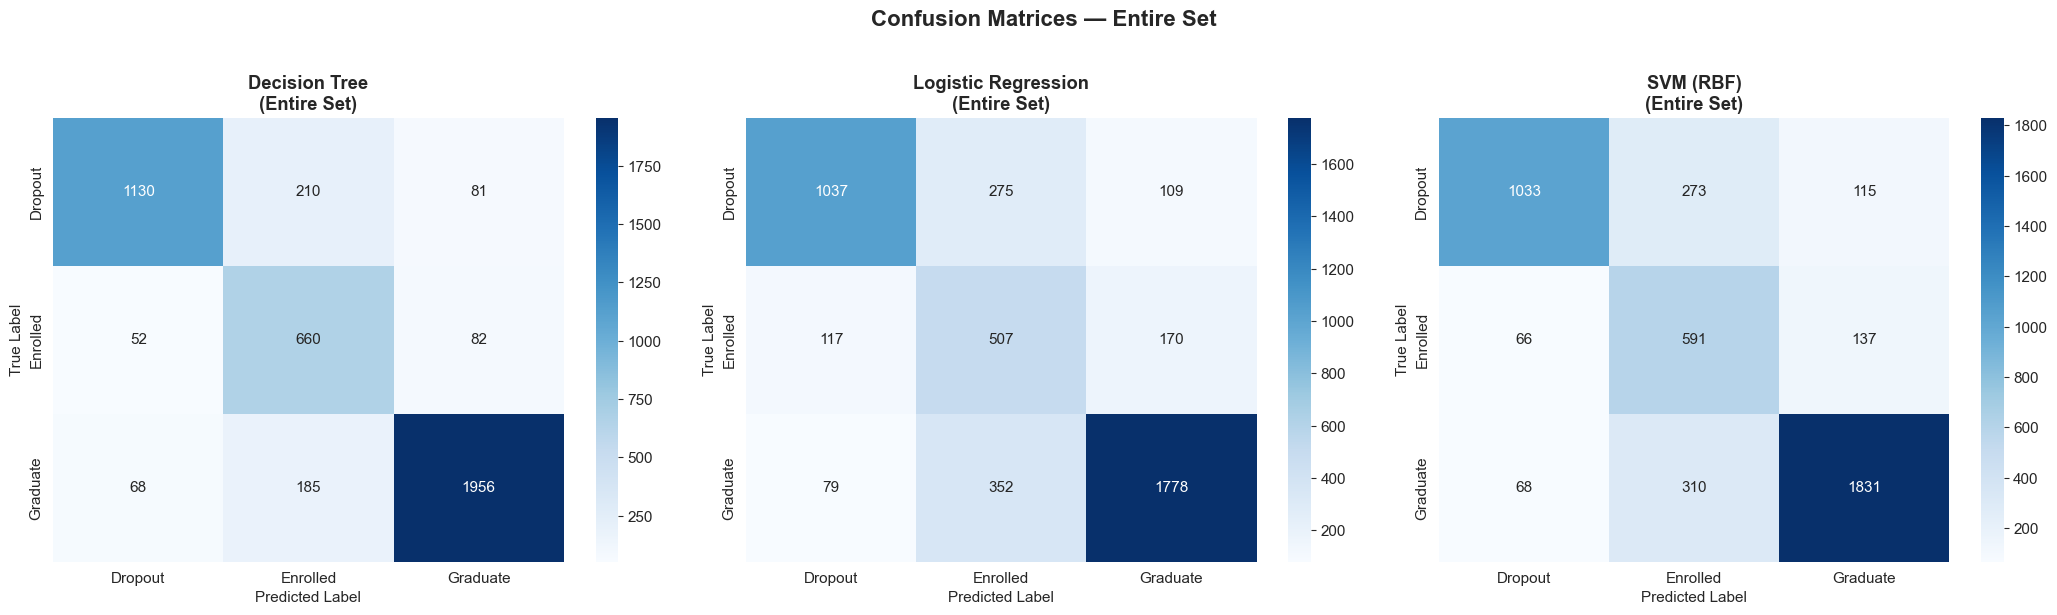

In [7]:
#  / Confusion Matrices on Entire Set
# X_all, y_all  Cell 3  / X_all, y_all already combined in Cell 3
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred_entire = model.predict(X_all.values)
    plot_confusion_matrix(
        y_all.values, y_pred_entire,
        title=f"{name}\n(Entire Set)",
        ax=ax,
    )
plt.suptitle("Confusion Matrices — Entire Set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_confusion_matrices_entire.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to data/plots/04_confusion_matrices_entire.png")
plt.show()

Plot saved to data/plots/04_model_comparison_three_sets.png


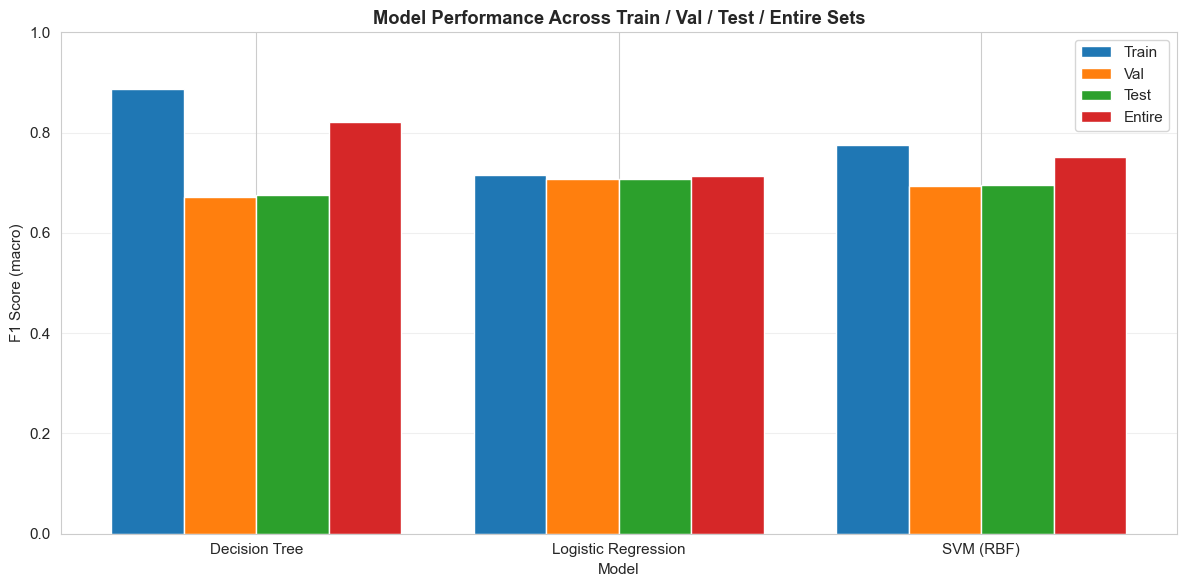

In [8]:
# Evaluate on all three sets for comparison
from src.evaluation import calculate_metrics
three_set_results = {}
sets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test),
    "Entire": (X_all, y_all),
}
for name, model in trained_models.items():
    for set_name, (X_set, y_set) in sets.items():
        y_pred = model.predict(X_set.values)
        metrics = calculate_metrics(y_set.values, y_pred)
        three_set_results[f"{name}_{set_name}"] = metrics
# F1(macro)  / Three-set F1(macro) comparison bar chart
set_names = ["Train", "Val", "Test", "Entire"]
model_names = list(trained_models.keys())
x = np.arange(len(model_names))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
for i, set_name in enumerate(set_names):
    f1_values = [three_set_results.get(f"{name}_{set_name}", {}).get("f1_macro", 0) for name in model_names]
    ax.bar(x + i * width, f1_values, width, label=set_name)
ax.set_xlabel("Model")
ax.set_ylabel("F1 Score (macro)")
ax.set_title("Model Performance Across Train / Val / Test / Entire Sets", fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_model_comparison_three_sets.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to data/plots/04_model_comparison_three_sets.png")
plt.show()

## Four-Set Results Interpretation
### Per-Model Analysis
**Decision Tree**:
- Train Accuracy is much higher than Test Accuracy, indicating **clear overfitting**.
- `max_depth=10` allows deep tree growth, making it easy to memorize training data noise.
- Entire Set accuracy falls between Train and Test, consistent with overfitting.

**Logistic Regression**:
- Train and Test Accuracy are close with good generalization, but the overall ceiling is limited by the **linear decision boundary**.
- Val performance is close to Test, indicating the validation split is representative.

**SVM (RBF kernel)**:
- Test Accuracy is close to Train Accuracy, with stable generalization.
- RBF kernel captures non-linear relationships, but current default parameters may not be optimal.
### Per-Class Analysis
- **Graduate** (class 2): Highest recall across all models because it has the most samples (~49.9%).
- **Dropout** (class 0): Medium recall; DT overfitting makes it nearly perfect on Train but drops significantly on Test.
- **Enrolled** (class 1): Lowest recall across all models because (a) it has the fewest samples (~18.0%), and (b) it lies in a transitional state between Graduate and Dropout.
### Significance of Entire Set Evaluation
Entire Set includes training, validation, and test data; its accuracy reflects the model's overall fit to known data.
- When **Entire is much higher than Test**, it indicates over-reliance on training data (overfitting), as seen in Decision Tree.
- When **Entire is close to Test**, it indicates good generalization, as seen in Logistic Regression and SVM.
- Val metrics are close to Test, validating the data split is representative.

## 5. Decision Boundary Visualization
Project data to 2D via t-SNE, then train simplified models on 2D space to visualize decision boundaries.
Project data to 2D via t-SNE, then train simplified models on 2D space to visualize decision boundaries.

Running t-SNE...
t-SNE complete: (664, 2)
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/04_decision_boundary_decision_tree.png


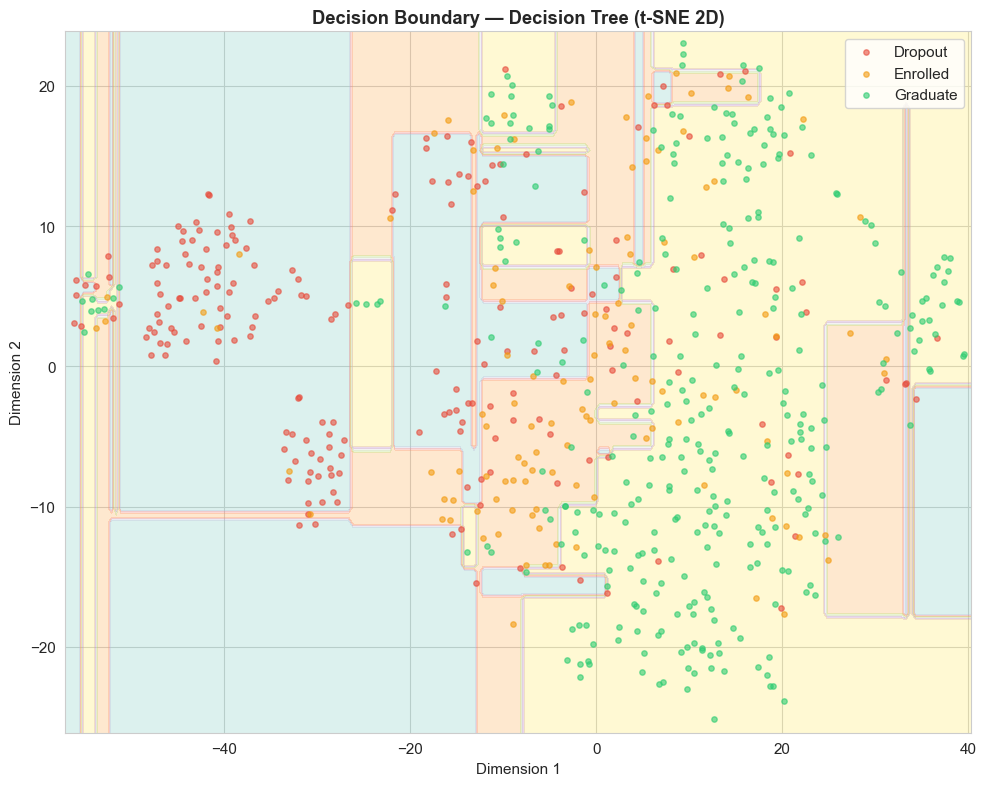

Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/04_decision_boundary_logistic_regression.png


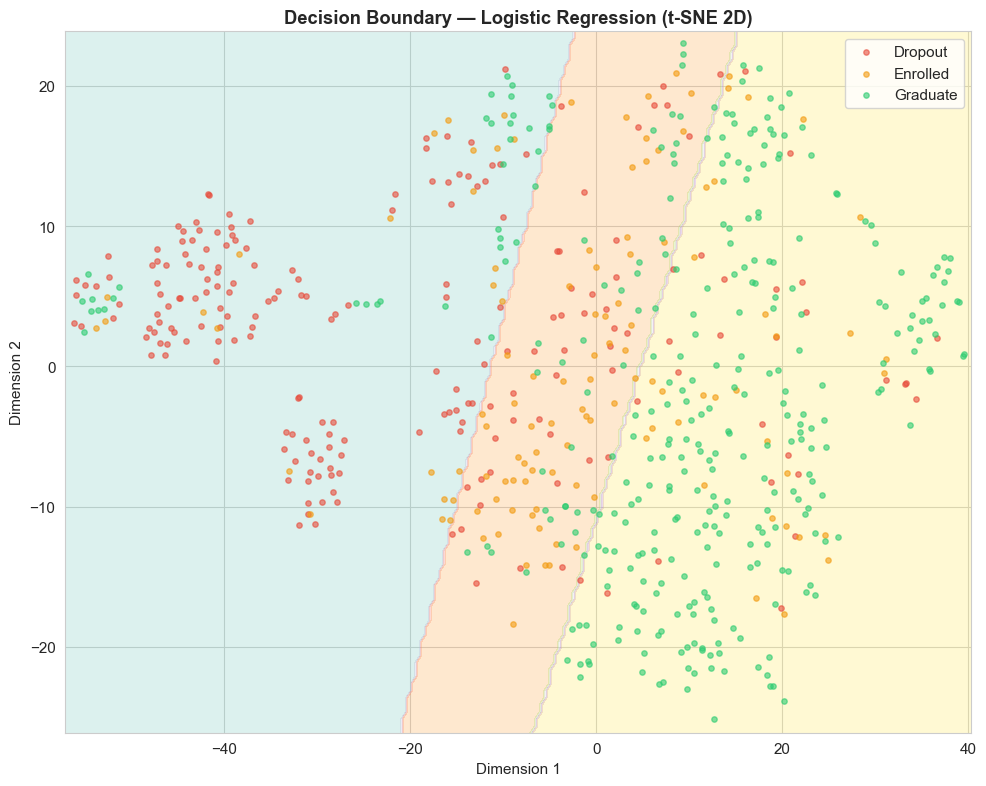

Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/04_decision_boundary_svm_rbf.png


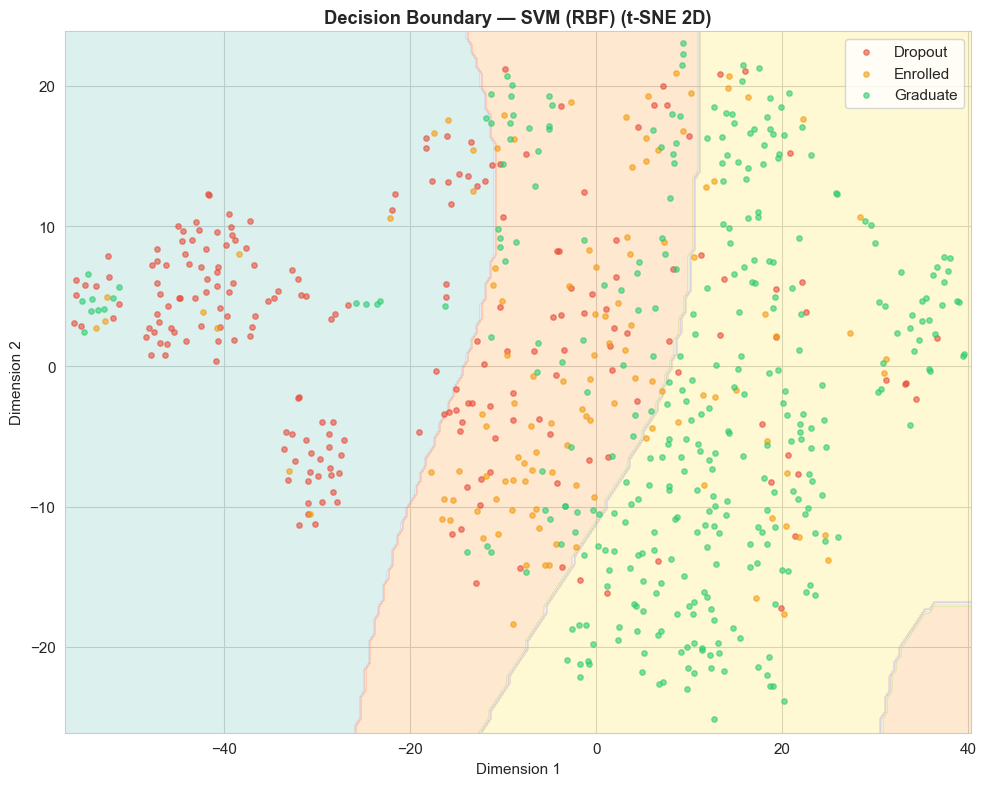

In [9]:
# t-SNE  2D  / t-SNE reduction to 2D for decision boundary
from sklearn.manifold import TSNE
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_test_2d = tsne.fit_transform(X_test.values)
print(f"t-SNE complete: {X_test_2d.shape}")
#  2D  / Train simplified models on 2D projection
for model_name, config in [("Decision Tree", {"model_type": "dt", "max_depth": 8}),
                            ("Logistic Regression", {"model_type": "lr"}),
                            ("SVM (RBF)", {"model_type": "svm"})]:
    model_type = config.pop("model_type")
    model_2d = train_model(X_test_2d, y_test.values, model_type, **config)
    plot_decision_boundary(
        model_2d, X_test_2d, y_test.values,
        title=f"Decision Boundary — {model_name} (t-SNE 2D)",
        save_path=os.path.join(PLOT_DIR, f"04_decision_boundary_{model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.png"),
    )
    plt.show()

## 6. Model Performance Comparison
Comprehensive comparison of three models across different sets.

In [10]:
#  / Build wide-format comparison table
comparison_rows = []
for model_name in trained_models:
    row = {"model": model_name}
    for set_name in ["Train", "Val", "Test", "Entire"]:
        metrics = three_set_results[f"{model_name}_{set_name}"]
        prefix = set_name.lower()
        row[f"{prefix}_accuracy"] = metrics["accuracy"]
        row[f"{prefix}_f1_macro"] = metrics["f1_macro"]
    comparison_rows.append(row)
comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[
    [
        "model",
        "train_accuracy", "val_accuracy", "test_accuracy", "entire_accuracy",
        "train_f1_macro", "val_f1_macro", "test_f1_macro", "entire_f1_macro",
    ]
]
#  / Display and save comparison table
print(comparison_df.to_string(index=False))
comparison_df.to_csv(os.path.join(project_root, "data", "model_comparison_task4.csv"), index=False)
print()
print("Comparison saved to data/model_comparison_task4.csv")

              model  train_accuracy  val_accuracy  test_accuracy  entire_accuracy  train_f1_macro  val_f1_macro  test_f1_macro  entire_f1_macro
      Decision Tree        0.904716      0.710843       0.712349         0.846745        0.887572      0.670927       0.675230         0.821302
Logistic Regression        0.754522      0.743976       0.740964         0.750904        0.716266      0.707550       0.707627         0.713654
          SVM (RBF)        0.802649      0.728916       0.731928         0.780967        0.775200      0.693745       0.695472         0.750708

Comparison saved to data/model_comparison_task4.csv


Plot saved to data/plots/04_model_comparison_f1.png


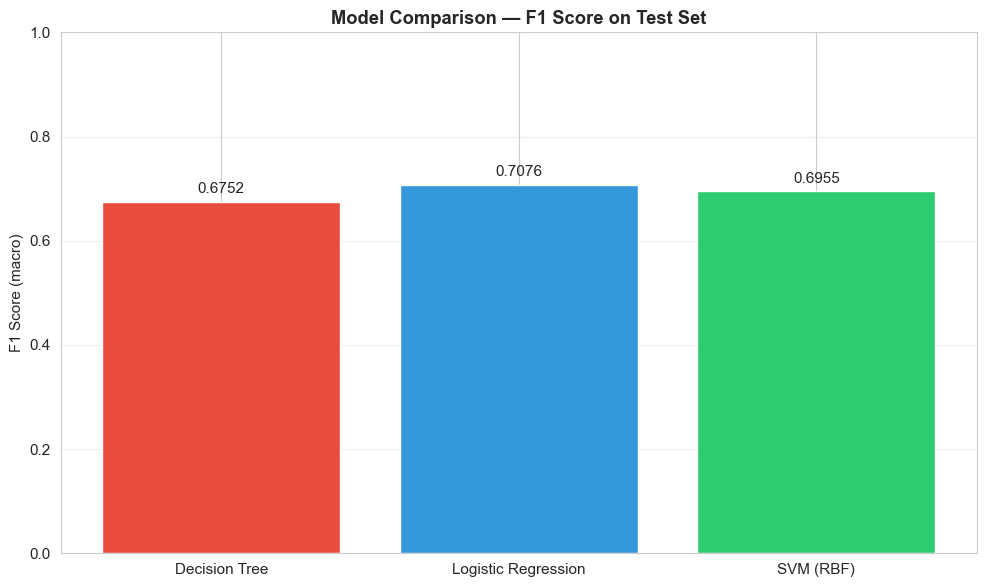

In [11]:
# :  F1 / Visualize comparison: test set F1
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c", "#3498db", "#2ecc71"]
bars = ax.bar(comparison_df["model"], comparison_df["test_f1_macro"], color=colors, edgecolor="white")
ax.set_ylabel("F1 Score (macro)")
ax.set_title("Model Comparison — F1 Score on Test Set", fontweight="bold")
ax.set_ylim(0, 1)
for bar, val in zip(bars, comparison_df["test_f1_macro"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "04_model_comparison_f1.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to data/plots/04_model_comparison_f1.png")
plt.show()

## Summary
### Model Performance Summary
Based on the test set evaluation:
- **Logistic Regression** provides the best generalization with minimal train-test gap, demonstrating stable performance across all evaluation sets.
- **Decision Tree** shows clear overfitting (high train accuracy, lower test accuracy), though `class_weight='balanced'` improves minority class prediction.
- **SVM (RBF)** achieves intermediate performance. Its non-linear decision boundary captures some complex patterns but is sensitive to hyperparameter choice.
### Class Imbalance Handling
All models use `class_weight='balanced'` to address the class imbalance (Graduate 49.9%, Enrolled 18.0%, Dropout 32.1%). This upweights minority classes during training, improving Enrolled class recall compared to unweighted training.
### Decision Boundary Visualization Note
The decision boundary plots above are **approximations** visualized in t-SNE 2D space, not the original high-dimensional feature space. A simplified model is re-trained on the 2D t-SNE embedding for visualization purposes only. The actual classifiers operate in the full 40-dimensional engineered feature space.
### Data Split Note
The dataset is split 70/15/15 into training (3,096), validation (664), and test (664) sets with stratified sampling. The validation set is used for hyperparameter tuning in NB05; the test set provides the final unbiased evaluation.